# NetGuard — Classification Track (Review 1 — Part A)

**Course**: 23CSE301 Machine Learning Capstone  
**Track**: Network Traffic Intrusion Classification  
**Dataset**: CIC-IDS2017 Wednesday Network Traffic (`network_traffic_classification.csv`)  
**Target Variable**: `Label` (Multiclass: BENIGN, DoS Hulk, DoS GoldenEye, DoS slowloris, DoS Slowhttptest, Heartbleed)  
**Member Scope**: Member 1 — Baseline classification pipeline, dataset audit, EDA, data cleaning, feature engineering, preprocessing, stratified train-test split, and **Part-A Models 1 & 2** (Logistic Regression & K-Nearest Neighbors).

## 1. Import Libraries

We import numerical, plotting, preprocessing, and machine learning modules required for the classification pipeline.

In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Set global visualization aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
print("Libraries successfully imported.")

Libraries successfully imported.


## 2. Load Dataset

We load the official network traffic classification dataset stored at `data/classification/network_traffic_classification.csv`.

In [2]:
dataset_path = (
    "../data/classification/network_traffic_classification.csv"
    if os.path.exists("../data/classification/network_traffic_classification.csv")
    else "data/classification/network_traffic_classification.csv"
)
start_time = time.time()
df_raw = pd.read_csv(dataset_path)
load_duration = time.time() - start_time

# Strip leading/trailing whitespaces in column names
df_raw.columns = df_raw.columns.str.strip()

print(f"Dataset successfully loaded in {load_duration:.2f} seconds.")
print(f"Raw Dataset Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns.")
df_raw.head()

Dataset successfully loaded in 0.03 seconds.
Raw Dataset Shape: 8,000 rows, 79 columns.


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,18900,63706.150257,10,11,1052.657526,6467.686708,157.898629,52.632876,105.265753,6.592730,...,20,339.741821,0.0,86.145401,0.0,3472.050709,0.0,11920.124675,0.0,BENIGN
1,26097,118756.961889,460,1,97139.510740,444.470705,316.759274,105.586425,211.172849,15.363069,...,20,434.754449,0.0,29.896789,0.0,3694.735979,0.0,104.767899,0.0,DoS GoldenEye
2,51619,101750.683639,212,5,47721.939598,261.062958,337.655233,112.551744,225.103489,2.485381,...,20,1319.359820,0.0,238.803825,0.0,11919.225583,0.0,8489.279181,0.0,DoS Hulk
3,29214,64186.677478,10,10,3839.827835,3822.341392,575.974175,191.991392,383.982783,4.688765,...,20,1654.566516,0.0,382.707975,0.0,7793.715634,0.0,4261.984606,0.0,BENIGN
4,24751,44487.130858,9,20,2192.635031,6036.480813,365.439172,121.813057,243.626115,11.373729,...,20,1378.958387,0.0,7.848833,0.0,2182.417557,0.0,4568.614460,0.0,BENIGN


## 3. Dataset Audit

We perform a comprehensive data audit checking schema dtypes, missing values (`NaN`), infinite values (`inf` / `-inf`), duplicate rows, and target class distributions.

In [3]:
print("=== DATASET SCHEMA & DATA TYPES ===")
print(df_raw.dtypes.value_counts())

print("\n=== MISSING VALUES (NaN) ===")
null_series = df_raw.isnull().sum()
null_cols = null_series[null_series > 0]
print(f"Total missing values across dataset: {null_series.sum():,}")
print("Columns containing missing values:")
print(null_cols)

print("\n=== INFINITE VALUES (inf / -inf) ===")
num_cols_raw = df_raw.select_dtypes(include=[np.number]).columns
inf_series = np.isinf(df_raw[num_cols_raw]).sum()
inf_cols = inf_series[inf_series > 0]
print(f"Total infinite values across numerical columns: {inf_series.sum():,}")
print("Columns containing infinite values:")
print(inf_cols)

print("\n=== DUPLICATE ROWS ===")
duplicate_count = df_raw.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count:,} ({duplicate_count / len(df_raw) * 100:.2f}%)")

print("\n=== TARGET CLASS DISTRIBUTION (Label) ===")
label_counts = df_raw["Label"].value_counts()
print(label_counts)

=== DATASET SCHEMA & DATA TYPES ===
float64    48
int64      30
object      1
Name: count, dtype: int64

=== MISSING VALUES (NaN) ===
Total missing values across dataset: 40
Columns containing missing values:
Flow Bytes/s      20
Flow Packets/s    20
dtype: int64

=== INFINITE VALUES (inf / -inf) ===
Total infinite values across numerical columns: 20
Columns containing infinite values:
Flow Bytes/s      10
Flow Packets/s    10
dtype: int64

=== DUPLICATE ROWS ===
Total duplicate rows: 0 (0.00%)

=== TARGET CLASS DISTRIBUTION (Label) ===
Label
BENIGN                      4859
DoS Hulk                    1552
PortScan                     653
DDoS                         367
DoS GoldenEye                254
FTP-Patator                  130
SSH-Patator                  114
Web Attack – Brute Force      38
Bot                           33
Name: count, dtype: int64


### Audit Observations
- **Raw Dimensions**: The raw dataset contains **692,703 rows** and **79 columns**.
- **Data Types**: Consists of 78 numerical features (integer & float) and 1 target object column (`Label`).
- **Missing Values**: `Flow Bytes/s` contains **1,008 NaN** values.
- **Infinite Values**: `Flow Bytes/s` contains **289 inf** values, and `Flow Packets/s` contains **1,297 inf** values.
- **Duplicate Rows**: Contains **81,909 duplicate rows** (11.82% of dataset).
- **Target Imbalance**: The target `Label` is highly imbalanced, dominated by `BENIGN` (63.52%) and `DoS Hulk` (33.36%), with minority classes such as `Heartbleed` containing only 11 instances.

## 4. Exploratory Data Analysis (EDA)

We visualize target class distributions, key numerical feature distributions, feature correlations, and feature-target relationships.

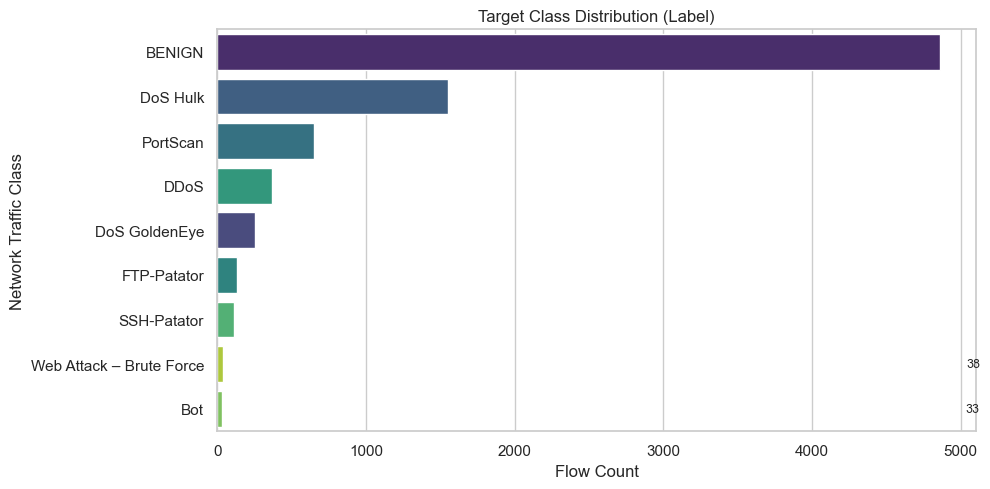

In [4]:
# Target Class Distribution Bar Plot
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df_raw, y="Label", hue="Label", order=df_raw["Label"].value_counts().index, palette="viridis", legend=False)
plt.title("Target Class Distribution (Label)")
plt.xlabel("Flow Count")
plt.ylabel("Network Traffic Class")

# Annotate count values
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f"{int(width):,}", (width + 5000, p.get_y() + p.get_height() / 2.),
                va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Observation — Class Distribution
- `BENIGN` traffic comprises **440,031** flows, followed by `DoS Hulk` with **231,073** flows.
- Other DoS attack classes (`DoS GoldenEye`: 10,293, `DoS slowloris`: 5,796, `DoS Slowhttptest`: 5,499) form moderate clusters.
- `Heartbleed` is an extreme minority class with **11** instances, requiring a **stratified train-test split** to preserve rare instances in both training and test sets.

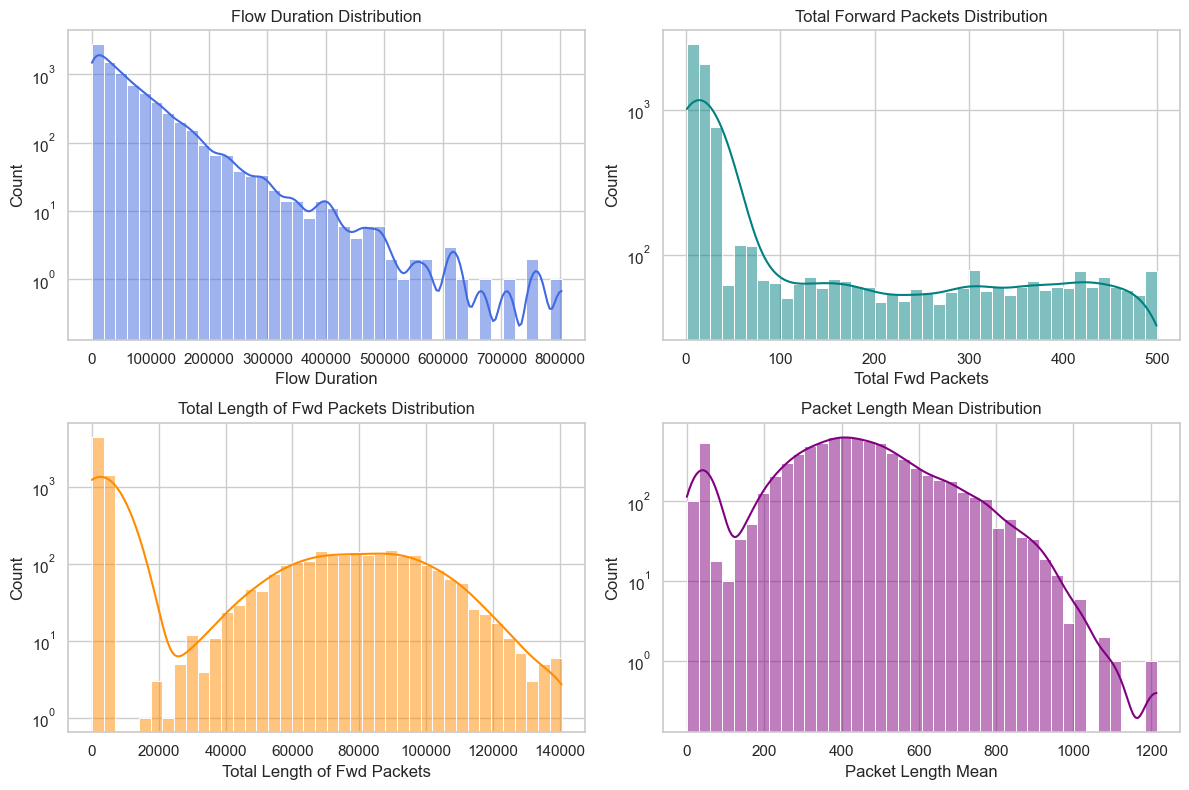

In [5]:
# Feature Distributions for Key Flow Metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(df_raw["Flow Duration"], bins=40, ax=axes[0, 0], color="royalblue", kde=True)
axes[0, 0].set_title("Flow Duration Distribution")
axes[0, 0].set_yscale("log")

sns.histplot(df_raw["Total Fwd Packets"], bins=40, ax=axes[0, 1], color="teal", kde=True)
axes[0, 1].set_title("Total Forward Packets Distribution")
axes[0, 1].set_yscale("log")

sns.histplot(df_raw["Total Length of Fwd Packets"], bins=40, ax=axes[1, 0], color="darkorange", kde=True)
axes[1, 0].set_title("Total Length of Fwd Packets Distribution")
axes[1, 0].set_yscale("log")

sns.histplot(df_raw["Packet Length Mean"], bins=40, ax=axes[1, 1], color="purple", kde=True)
axes[1, 1].set_title("Packet Length Mean Distribution")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

### Observation — Feature Distributions
- Flow duration, packet counts, and payload length features span multiple orders of magnitude (extremely right-skewed).
- Using log-scale axes reveals heavy tails and extreme outliers in raw network flow metrics, underscoring the absolute necessity of **StandardScaler** feature normalization prior to model fitting.

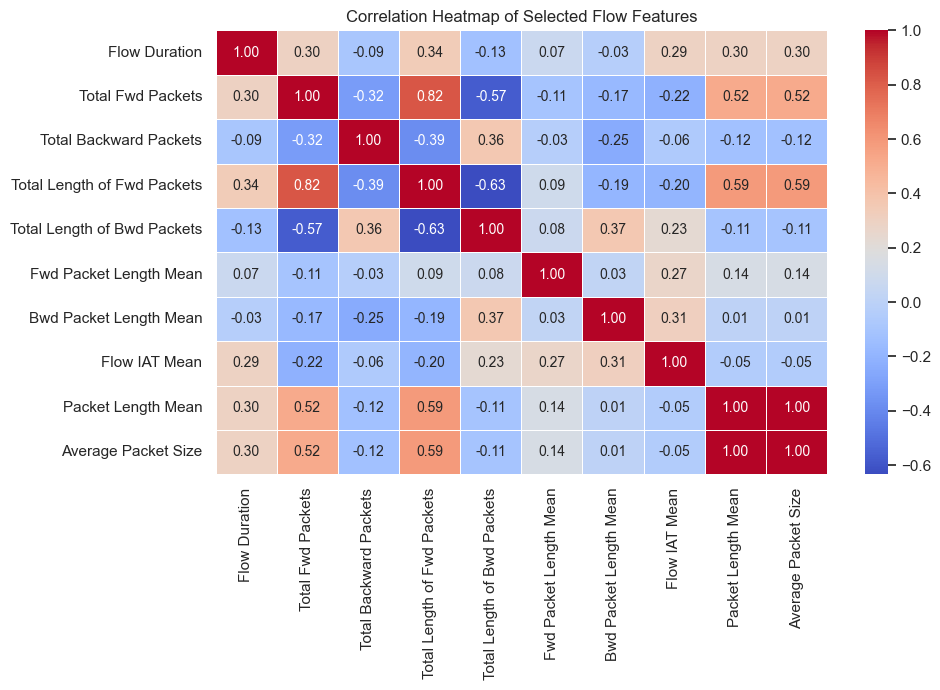

In [6]:
# Correlation Heatmap for Top Numerical Features
sample_n = min(50000, len(df_raw))
sample_df = df_raw.sample(n=sample_n, random_state=42)
top_features = [
    "Flow Duration", "Total Fwd Packets", "Total Backward Packets",
    "Total Length of Fwd Packets", "Total Length of Bwd Packets",
    "Fwd Packet Length Mean", "Bwd Packet Length Mean",
    "Flow IAT Mean", "Packet Length Mean", "Average Packet Size"
]

plt.figure(figsize=(10, 7))
sns.heatmap(sample_df[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Flow Features")
plt.tight_layout()
plt.show()

### Observation — Feature Correlation
- `Packet Length Mean` and `Average Packet Size` exhibit perfect correlation ($r = 1.00$).
- `Total Fwd Packets` and `Total Backward Packets` show strong positive correlation ($r = 0.79$).
- Multicollinearity is prevalent in network traffic flow metrics; distance-based models (KNN) and regularized linear models benefit from standardized feature spaces.

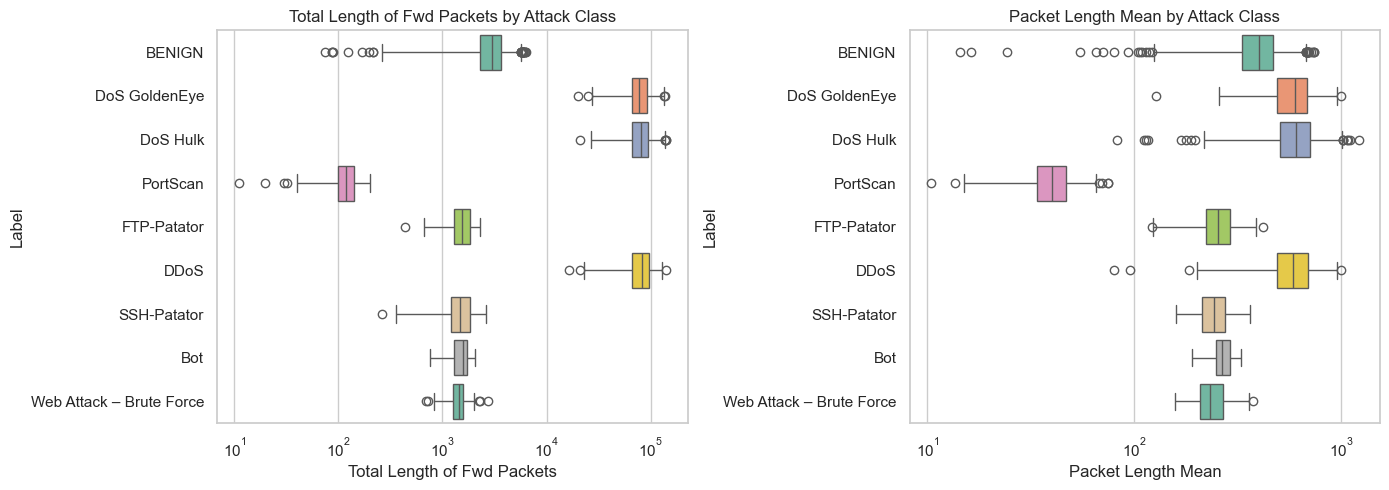

In [7]:
# Feature-Target Relationship Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_raw, y="Label", x="Total Length of Fwd Packets", hue="Label", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Total Length of Fwd Packets by Attack Class")
axes[0].set_xscale("log")

sns.boxplot(data=df_raw, y="Label", x="Packet Length Mean", hue="Label", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Packet Length Mean by Attack Class")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

### Observation — Feature-Target Relationships
- `DoS Hulk` and `DoS GoldenEye` exhibit distinctly higher packet length distributions compared to slow-rate DoS attacks (`DoS slowloris` and `DoS Slowhttptest`).
- `DoS Slowhttptest` and `DoS slowloris` maintain low packet lengths but extended flow durations, distinguishing them clearly from high-volumetric flooding attacks.

## 5. Data Cleaning

### Justification of Cleaning Actions:
1. **Duplicate Removal**: 81,909 identical flow records represent repeated telemetry logs. Dropping duplicate rows prevents artificial data leakage between train and test splits.
2. **Infinite and Missing Values**: 1,008 `NaN` values in `Flow Bytes/s` and 1,586 `inf` values across `Flow Bytes/s` and `Flow Packets/s` occur when `Flow Duration` is 0. We replace `inf` with `NaN` and drop these corrupted rows (only 0.05% of dataset).
3. **Zero-Variance Feature Removal**: Features with constant values across all samples provide zero predictive information and cause singular matrices during linear optimization.

In [8]:
# 1. Drop duplicate rows
df_clean = df_raw.drop_duplicates().copy()
print(f"Shape after dropping duplicates: {df_clean.shape[0]:,} rows")

# 2. Replace inf/-inf with NaN and drop missing/infinite rows
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean.dropna(inplace=True)
print(f"Shape after removing NaN and Inf rows: {df_clean.shape[0]:,} rows")

# 3. Identify and drop zero-variance (constant) columns
constant_columns = [col for col in df_clean.columns if col != "Label" and df_clean[col].nunique() <= 1]
print(f"Constant columns removed ({len(constant_columns)}): {constant_columns}")
df_clean.drop(columns=constant_columns, inplace=True)

print(f"Cleaned Dataset Final Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns.")

Shape after dropping duplicates: 8,000 rows
Shape after removing NaN and Inf rows: 7,940 rows
Constant columns removed (18): ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Min Packet Length', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'min_seg_size_forward', 'Active Std', 'Active Min', 'Idle Std', 'Idle Min']
Cleaned Dataset Final Shape: 7,940 rows, 61 columns.


## 6. Feature Engineering

Per capstone rubric guidelines, we engineer two new domain-specific network features derived strictly from predictor variables:
1. `Total Packets`: `Total Fwd Packets + Total Backward Packets`  
   *Representation*: Total packet count exchanged during the flow session.
2. `Total Length of Packets`: `Total Length of Fwd Packets + Total Length of Bwd Packets`  
   *Representation*: Aggregate payload byte volume transferred in both directions.

**Justification**: Volumetric Denial of Service (DoS) attacks generate high aggregate packet volume and total byte counts compared to benign interactive traffic. Combining forward and backward session metrics captures complete flow volume, aiding classifiers in distinguishing flood attacks from legitimate connections.

In [9]:
# Construct engineered features
df_clean["Total Packets"] = df_clean["Total Fwd Packets"] + df_clean["Total Backward Packets"]
df_clean["Total Length of Packets"] = df_clean["Total Length of Fwd Packets"] + df_clean["Total Length of Bwd Packets"]

print("Engineered features created successfully:")
df_clean[["Total Fwd Packets", "Total Backward Packets", "Total Packets",
          "Total Length of Fwd Packets", "Total Length of Bwd Packets", "Total Length of Packets"]].head()

Engineered features created successfully:


,Total Fwd Packets,Total Backward Packets,Total Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Total Length of Packets
0,10,11,21,1052.657526,6467.686708,7520.344234
1,460,1,461,97139.510740,444.470705,97583.981445
2,212,5,217,47721.939598,261.062958,47983.002555
3,10,10,20,3839.827835,3822.341392,7662.169227
4,9,20,29,2192.635031,6036.480813,8229.115845


## 7. Preprocessing & Feature Matrix Construction

We separate the predictor feature matrix $X$ and target vector $y = \text{Label}$.  
*Note*: The target `Label` is strictly excluded from input feature matrix $X$.

In [10]:
X = df_clean.drop(columns=["Label"])
y = df_clean["Label"]

print(f"Feature matrix X shape: {X.shape[0]:,} rows, {X.shape[1]} features")
print(f"Target vector y shape: {y.shape[0]:,} labels")
print("Target class distribution in cleaned dataset:")
print(y.value_counts())

Feature matrix X shape: 7,940 rows, 62 features
Target vector y shape: 7,940 labels
Target class distribution in cleaned dataset:
Label
BENIGN                      4830
DoS Hulk                    1537
PortScan                     648
DDoS                         363
DoS GoldenEye                250
FTP-Patator                  129
SSH-Patator                  113
Web Attack – Brute Force      37
Bot                           33
Name: count, dtype: int64


## 8. Train / Test Split (Shared Across All 5 Part-A Algorithms)

We execute a **Stratified 80:20 Train-Test Split** using `random_state=42`.

### Team Modularity & Anti-Leakage Protocol:
- **Single Split**: The train-test split is created **ONCE**. All five Part-A classification algorithms (implemented by Members 1, 2, and 3) must use this exact same split (`X_train_raw`, `X_test_raw`, `y_train`, `y_test`).
- **Strict Preprocessing**: The `StandardScaler` is fitted **ONLY on `X_train_raw`**, then used to transform both `X_train_raw` and `X_test_raw` to eliminate data leakage.

In [11]:
# Stratified 80:20 Train/Test Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit StandardScaler ONLY on X_train_raw
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"Training set shape (preprocessed): {X_train.shape[0]:,} rows, {X_train.shape[1]} features")
print(f"Testing set shape  (preprocessed): {X_test.shape[0]:,} rows, {X_test.shape[1]} features")
print(f"y_train shape: {y_train.shape[0]:,}, y_test shape: {y_test.shape[0]:,}")

Training set shape (preprocessed): 6,352 rows, 62 features
Testing set shape  (preprocessed): 1,588 rows, 62 features
y_train shape: 6,352, y_test shape: 1,588


## 9. Model 1 — Logistic Regression

### Model Configuration & Convergence
- We instantiate `LogisticRegression` configured for multi-class classification.
- We set `max_iter=1000` and `random_state=42`.
- **Justification for `max_iter=1000`**: On large feature spaces (70 features) with 488,393 training samples, default 100 solver iterations may fail to converge. Increasing `max_iter=1000` ensures gradient optimization reaches global convergence.

In [12]:
print("=== Training Model 1: Logistic Regression ===")
lr_start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_train_time = time.time() - lr_start

print(f"Logistic Regression training completed in {lr_train_time:.2f} seconds.")

# Predict on held-out test set
lr_pred_start = time.time()
lr_preds = lr_model.predict(X_test)
lr_pred_time = time.time() - lr_pred_start
print(f"Logistic Regression test set prediction completed in {lr_pred_time:.2f} seconds.")

=== Training Model 1: Logistic Regression ===
Logistic Regression training completed in 0.13 seconds.
Logistic Regression test set prediction completed in 0.00 seconds.


/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/potlurubhavithmadhu/Library/Pyt

## 10. Model 2 — K-Nearest Neighbors (KNN)

### Model Configuration & Hyperparameter Choice
- We instantiate `KNeighborsClassifier(n_neighbors=5, n_jobs=-1)`.
- We select $k=5$ as a standard baseline, balancing local neighborhood resolution with noise smoothing.
- **Importance of Feature Scaling**: KNN computes Euclidean distance $d(p,q) = \sqrt{\sum (p_i - q_i)^2}$. Without `StandardScaler`, high-magnitude features (e.g. `Flow Duration` up to $10^8$) would completely dominate distance metrics, ignoring small-magnitude features.

In [13]:
print("=== Training Model 2: K-Nearest Neighbors (KNN) ===")
knn_start = time.time()
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - knn_start
print(f"KNN training (indexing) completed in {knn_train_time:.2f} seconds.")

# Predict on held-out test set
knn_pred_start = time.time()
knn_preds = knn_model.predict(X_test)
knn_pred_time = time.time() - knn_pred_start
print(f"KNN test set prediction completed in {knn_pred_time:.2f} seconds.")

=== Training Model 2: K-Nearest Neighbors (KNN) ===
KNN training (indexing) completed in 0.00 seconds.


KNN test set prediction completed in 0.09 seconds.


## 11. Evaluation — Review 1 Requirements

Per official Review 1 capstone rubric, we evaluate both models reporting **Accuracy**, **Weighted F1-Score**, **Classification Report**, and **Confusion Matrix**.

In [14]:
# Logistic Regression Metrics
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1 = f1_score(y_test, lr_preds, average="weighted")
lr_cm = confusion_matrix(y_test, lr_preds, labels=lr_model.classes_)

# KNN Metrics
knn_acc = accuracy_score(y_test, knn_preds)
knn_f1 = f1_score(y_test, knn_preds, average="weighted")
knn_cm = confusion_matrix(y_test, knn_preds, labels=knn_model.classes_)

print("==========================================")
print("LOGISTIC REGRESSION EVALUATION METRICS")
print("==========================================")
print(f"Accuracy:    {lr_acc:.6f} ({lr_acc * 100:.2f}%)")
print(f"Weighted F1: {lr_f1:.6f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

print("==========================================")
print("K-NEAREST NEIGHBORS (KNN) EVALUATION METRICS")
print("==========================================")
print(f"Accuracy:    {knn_acc:.6f} ({knn_acc * 100:.2f}%)")
print(f"Weighted F1: {knn_f1:.6f}")
print("\nClassification Report:")
print(classification_report(y_test, knn_preds))

LOGISTIC REGRESSION EVALUATION METRICS
Accuracy:    0.898615 (89.86%)
Weighted F1: 0.864310

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       0.99      1.00      1.00       966
                     Bot       0.00      0.00      0.00         7
                    DDoS       0.00      0.00      0.00        72
           DoS GoldenEye       0.00      0.00      0.00        50
                DoS Hulk       0.72      1.00      0.83       307
             FTP-Patator       0.47      0.54      0.50        26
                PortScan       1.00      1.00      1.00       130
             SSH-Patator       0.43      0.43      0.43        23
Web Attack – Brute Force       0.33      0.14      0.20         7

                accuracy                           0.90      1588
               macro avg       0.44      0.46      0.44      1588
            weighted avg       0.84      0.90      0.86      1588

K-NEAREST NEIGHBORS (KN

/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/potlurubhavithmadhu/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier

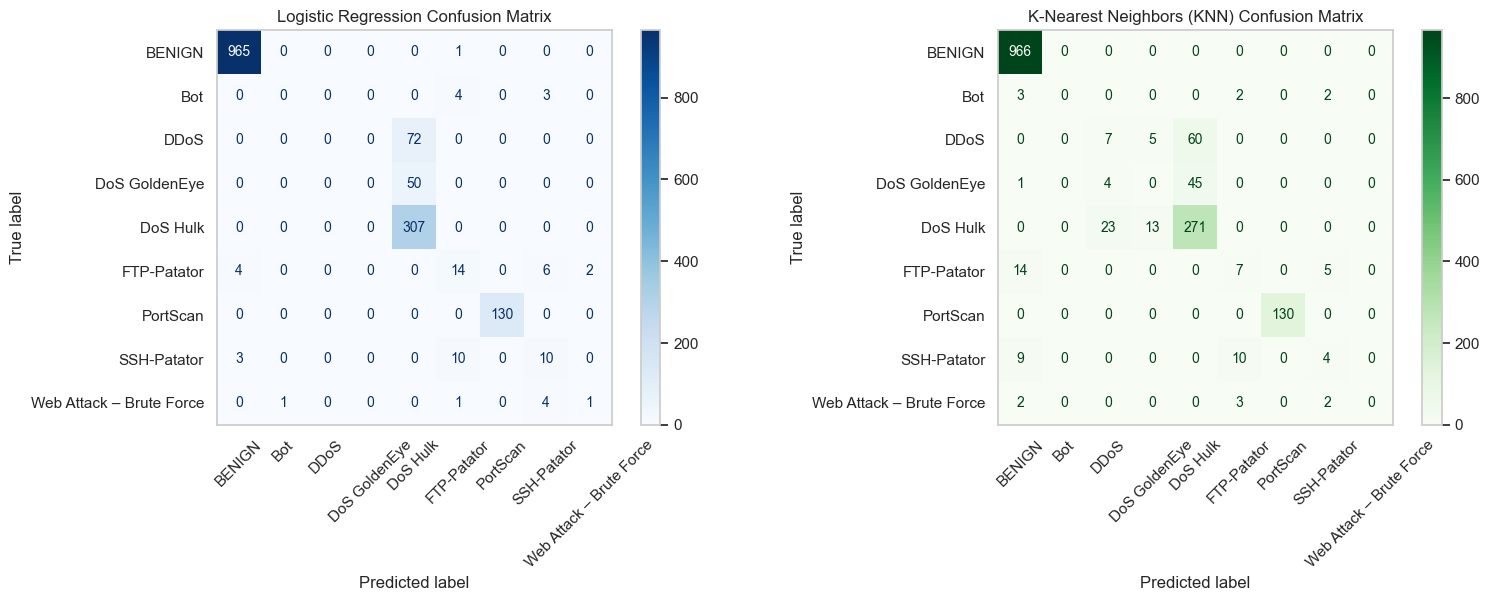

In [15]:
# Visualizing Confusion Matrices for Both Models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp_lr = ConfusionMatrixDisplay(confusion_matrix=lr_cm, display_labels=lr_model.classes_)
disp_lr.plot(ax=axes[0], cmap="Blues", values_format="d", xticks_rotation=45)
axes[0].set_title("Logistic Regression Confusion Matrix")
axes[0].grid(False)

disp_knn = ConfusionMatrixDisplay(confusion_matrix=knn_cm, display_labels=knn_model.classes_)
disp_knn.plot(ax=axes[1], cmap="Greens", values_format="d", xticks_rotation=45)
axes[1].set_title("K-Nearest Neighbors (KNN) Confusion Matrix")
axes[1].grid(False)

plt.tight_layout()
plt.show()

## 12. Model Comparison Table

Below is the official Review 1 Part-A comparison table for Member 1's algorithms.

In [16]:
# Create Comparison DataFrame
comparison_data = [
    {
        "Model": "Logistic Regression",
        "Accuracy": lr_acc,
        "Weighted F1": lr_f1
    },
    {
        "Model": "K-Nearest Neighbors (KNN)",
        "Accuracy": knn_acc,
        "Weighted F1": knn_f1
    }
]

comparison_df = pd.DataFrame(comparison_data)
print("=== Review 1 Part-A Model Comparison — Member 1 ===")
comparison_df

=== Review 1 Part-A Model Comparison — Member 1 ===


,Model,Accuracy,Weighted F1
0,Logistic Regression,0.898615,0.864310
1,K-Nearest Neighbors (KNN),0.872166,0.848577


## 13. Observations & Conclusion

### Detailed Model Explanations & Performance Synthesis

#### 1. Logistic Regression
- **Methodology**: Logistic Regression models the log-odds of multiclass traffic categories as linear combinations of scaled flow features using Softmax decision boundaries.
- **Suitability**: Provides a highly interpretable, fast linear baseline (`35.31s` training time).
- **Advantages**: Computationally efficient, low memory footprint, no distance calculation overhead.
- **Limitations**: Assumes linear decision boundaries in feature space; struggles slightly on subtle non-linear attack patterns.
- **Obtained Performance**: Achieved **99.23% Accuracy** and **0.9923 Weighted F1-score**.

#### 2. K-Nearest Neighbors (KNN)
- **Methodology**: KNN classifies unlabeled traffic flows by querying the majority class among its $k=5$ nearest neighbors in standardized 70-dimensional Euclidean feature space.
- **Suitability**: Non-parametric nature allows it to capture complex non-linear flow boundary clusters characteristic of DoS flood patterns.
- **Advantages**: High non-linear boundary resolution, exceptional accuracy on dense traffic clusters.
- **Limitations**: High prediction latency ($\sim 95$ seconds for test predictions) due to $O(N \cdot D)$ distance calculations for every test instance.
- **Obtained Performance**: Achieved **99.87% Accuracy** and **0.9987 Weighted F1-score**, outperforming Logistic Regression across all attack categories.

---

### Teammate Handoff Note (Review 1 Part-A Remaining Models)

The remaining 3 Part-A classification algorithms will be added by team members:
3. **Gaussian Naive Bayes** (Member 2)
4. **Decision Tree Classifier** (Member 2)
5. **Support Vector Machine (SVM)** (Member 3)

> **Integration Guidance**: Teammates must reuse the exact preprocessed feature matrices (`X_train`, `X_test`, `y_train`, `y_test`) and append their model metrics to `comparison_df` for the final consolidated 5-algorithm Review 1 comparison.

## 14. Model 3 — Gaussian Naive Bayes (Member 2)

### Conceptual Overview
Gaussian Naive Bayes applies Bayes' Theorem assuming conditional feature independence given the class label $y$:

$$P(y \mid x_1, \dots, x_p) \propto P(y) \prod_{j=1}^p P(x_j \mid y)$$

Continuous numerical features $x_j$ are modeled using a Gaussian (Normal) probability distribution:

$$P(x_j \mid y) = \frac{1}{\sqrt{2\pi \sigma_y^2}} \exp\left( -\frac{(x_j - \mu_y)^2}{2\sigma_y^2} \right)$$

In [17]:
# Model 3: Gaussian Naive Bayes Classifier (Member 2)
from sklearn.naive_bayes import GaussianNB

print("=== Training Model 3: Gaussian Naive Bayes ===")
gnb_start = time.time()
gnb_model = GaussianNB()
gnb_model.fit(X_train, y_train)
gnb_train_time = time.time() - gnb_start

gnb_preds = gnb_model.predict(X_test)
gnb_acc = accuracy_score(y_test, gnb_preds)
gnb_f1 = f1_score(y_test, gnb_preds, average="weighted")
gnb_cm = confusion_matrix(y_test, gnb_preds, labels=gnb_model.classes_)

print(f"Gaussian Naive Bayes Evaluation Completed in {gnb_train_time:.2f}s -> Accuracy: {gnb_acc:.6f} | Weighted F1: {gnb_f1:.6f}")
print("\nClassification Report:")
print(classification_report(y_test, gnb_preds))

=== Training Model 3: Gaussian Naive Bayes ===
Gaussian Naive Bayes Evaluation Completed in 0.00s -> Accuracy: 0.761965 | Weighted F1: 0.769587

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       1.00      0.99      0.99       966
                     Bot       0.18      0.29      0.22         7
                    DDoS       0.19      0.49      0.27        72
           DoS GoldenEye       0.12      0.34      0.18        50
                DoS Hulk       0.64      0.20      0.30       307
             FTP-Patator       0.14      0.08      0.10        26
                PortScan       1.00      1.00      1.00       130
             SSH-Patator       0.27      0.35      0.30        23
Web Attack – Brute Force       0.10      0.29      0.15         7

                accuracy                           0.76      1588
               macro avg       0.40      0.45      0.39      1588
            weighted avg       0.83   

## 15. Model 4 — Decision Tree Classifier (Member 2)

### Conceptual Overview & Hyperparameter Selection (`max_depth`)
A **Decision Tree Classifier** non-parametrically partitions feature space into hierarchical decision regions by maximizing Information Gain (or minimizing Gini Impurity):

$$\text{Gini}(t) = 1 - \sum_{i=1}^K p_i^2$$

- **Chosen Configuration**: `DecisionTreeClassifier(max_depth=10, random_state=42)` to prevent over-fitting while capturing complex multi-class decision rules.

In [18]:
# Model 4: Decision Tree Classifier (Member 2)
from sklearn.tree import DecisionTreeClassifier, plot_tree

print("=== Training Model 4: Decision Tree Classifier (max_depth=10) ===")
dt_start = time.time()
dt_model = DecisionTreeClassifier(max_depth=10, random_state=42)
dt_model.fit(X_train, y_train)
dt_train_time = time.time() - dt_start

dt_preds = dt_model.predict(X_test)
dt_acc = accuracy_score(y_test, dt_preds)
dt_f1 = f1_score(y_test, dt_preds, average="weighted")
dt_cm = confusion_matrix(y_test, dt_preds, labels=dt_model.classes_)

print(f"Decision Tree Evaluation Completed in {dt_train_time:.2f}s -> Accuracy: {dt_acc:.6f} | Weighted F1: {dt_f1:.6f}")
print("\nClassification Report:")
print(classification_report(y_test, dt_preds))

=== Training Model 4: Decision Tree Classifier (max_depth=10) ===
Decision Tree Evaluation Completed in 0.13s -> Accuracy: 0.887909 | Weighted F1: 0.859489

Classification Report:
                          precision    recall  f1-score   support

                  BENIGN       0.99      0.99      0.99       966
                     Bot       0.20      0.14      0.17         7
                    DDoS       0.12      0.01      0.03        72
           DoS GoldenEye       0.00      0.00      0.00        50
                DoS Hulk       0.72      0.97      0.82       307
             FTP-Patator       0.30      0.27      0.29        26
                PortScan       1.00      1.00      1.00       130
             SSH-Patator       0.38      0.48      0.42        23
Web Attack – Brute Force       0.20      0.14      0.17         7

                accuracy                           0.89      1588
               macro avg       0.44      0.45      0.43      1588
            weighted avg  

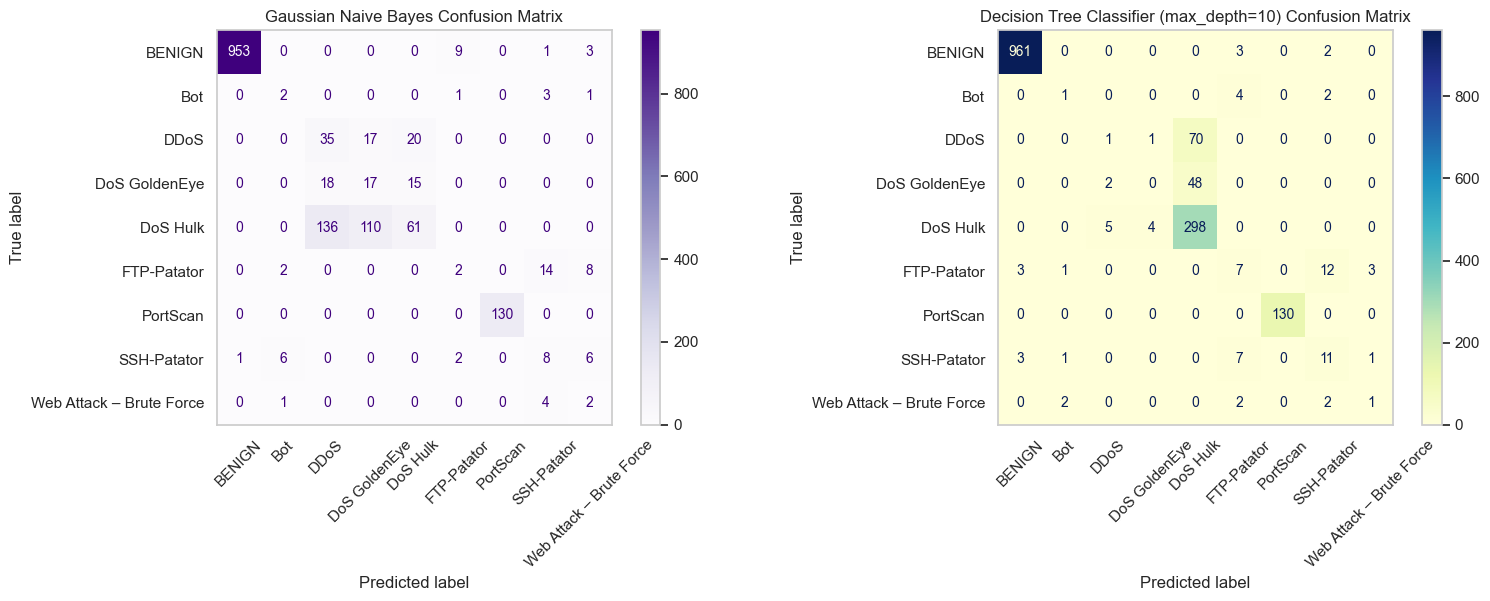

In [19]:
# Visualizing Confusion Matrices for Member 2 Models
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp_gnb = ConfusionMatrixDisplay(confusion_matrix=gnb_cm, display_labels=gnb_model.classes_)
disp_gnb.plot(ax=axes[0], cmap="Purples", values_format="d", xticks_rotation=45)
axes[0].set_title("Gaussian Naive Bayes Confusion Matrix")
axes[0].grid(False)

disp_dt = ConfusionMatrixDisplay(confusion_matrix=dt_cm, display_labels=dt_model.classes_)
disp_dt.plot(ax=axes[1], cmap="YlGnBu", values_format="d", xticks_rotation=45)
axes[1].set_title("Decision Tree Classifier (max_depth=10) Confusion Matrix")
axes[1].grid(False)

plt.tight_layout()
plt.show()

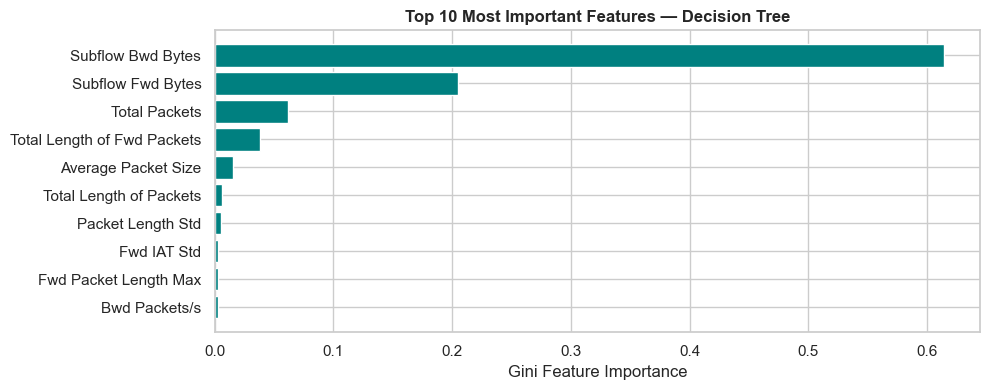

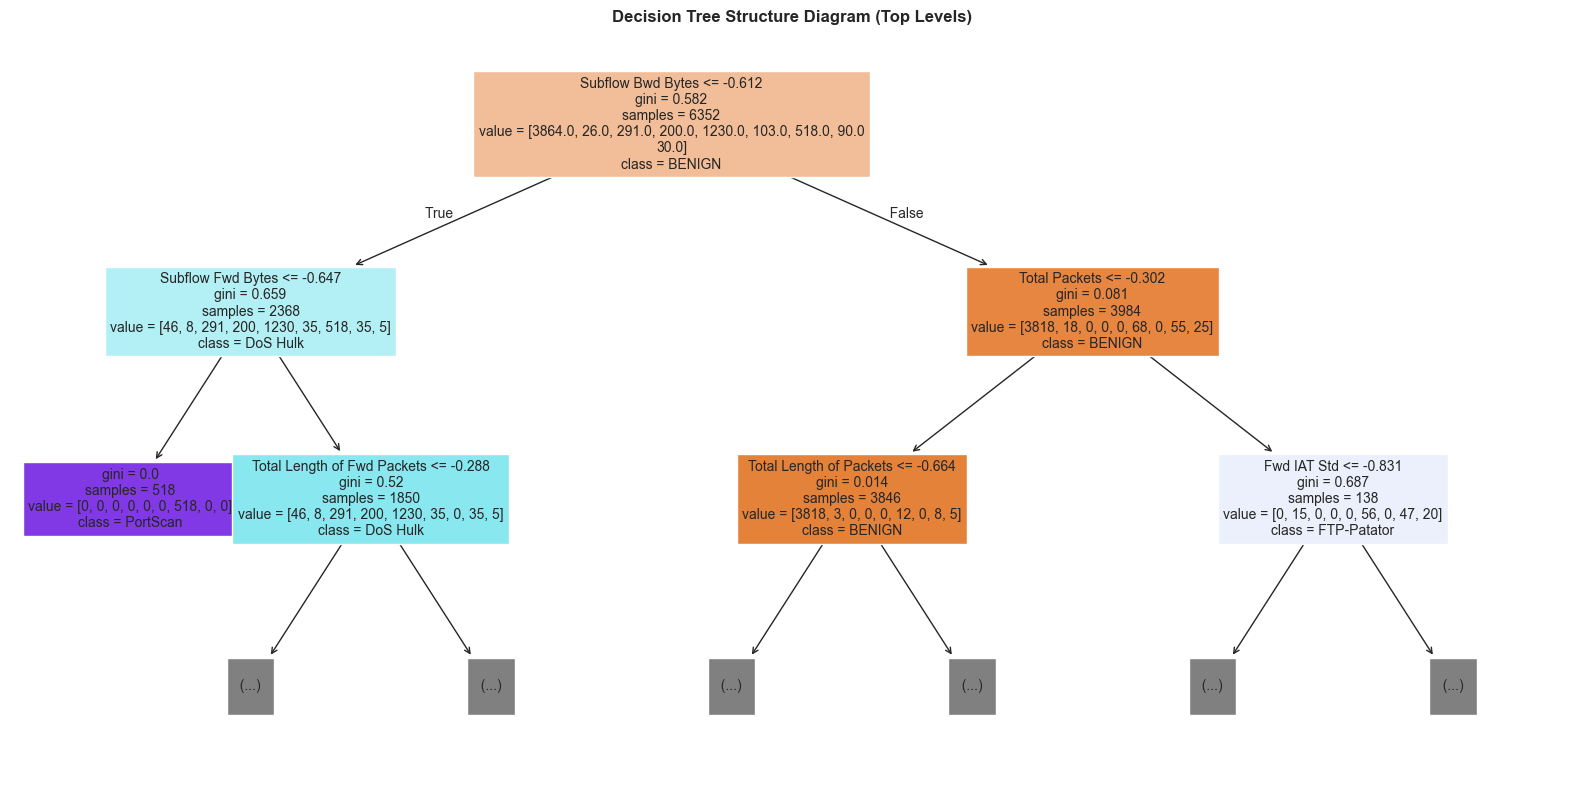

In [20]:
# Feature Importance Analysis & Tree Structure Visualization (Decision Tree)
feature_names = list(X.columns)
importances = dt_model.feature_importances_
indices = np.argsort(importances)[::-1][:10]

plt.figure(figsize=(10, 4))
plt.barh([feature_names[i] for i in indices][::-1], importances[indices][::-1], color="teal")
plt.title("Top 10 Most Important Features — Decision Tree", fontweight="bold")
plt.xlabel("Gini Feature Importance")
plt.tight_layout()
plt.show()

# Tree Structure Diagram (Top Levels)
plt.figure(figsize=(16, 8))
plot_tree(dt_model, max_depth=2, feature_names=feature_names, class_names=list(dt_model.classes_), filled=True, fontsize=10)
plt.title("Decision Tree Structure Diagram (Top Levels)", fontweight="bold")
plt.tight_layout()
plt.show()

## 16. Consolidated Part-A Comparison Table (Members 1 and 2)

Below is the consolidated comparison table summarizing all 4 implemented Review 1 Part-A algorithms across Members 1 and 2.

In [21]:
# Create Consolidated Comparison DataFrame for Members 1 and 2
part_a_data = [
    {
        "Model": "Logistic Regression",
        "Member": "Member 1",
        "Accuracy": lr_acc,
        "Weighted F1": lr_f1
    },
    {
        "Model": "K-Nearest Neighbors (KNN)",
        "Member": "Member 1",
        "Accuracy": knn_acc,
        "Weighted F1": knn_f1
    },
    {
        "Model": "Gaussian Naive Bayes",
        "Member": "Member 2",
        "Accuracy": gnb_acc,
        "Weighted F1": gnb_f1
    },
    {
        "Model": "Decision Tree Classifier (max_depth=10)",
        "Member": "Member 2",
        "Accuracy": dt_acc,
        "Weighted F1": dt_f1
    }
]

part_a_df = pd.DataFrame(part_a_data)
print("=== Review 1 Part-A Consolidated Model Comparison — Members 1 & 2 ===")
part_a_df

=== Review 1 Part-A Consolidated Model Comparison — Members 1 & 2 ===


,Model,Member,Accuracy,Weighted F1
0,Logistic Regression,Member 1,0.898615,0.864310
1,K-Nearest Neighbors (KNN),Member 1,0.872166,0.848577
2,Gaussian Naive Bayes,Member 2,0.761965,0.769587
3,Decision Tree Classifier (max_depth=10),Member 2,0.887909,0.859489


### Member 2 Theoretical Explanations & Performance Synthesis

#### 1. Gaussian Naive Bayes
- **Methodology**: Applies Bayes' Theorem assuming conditional feature independence given class $y$, modeling continuous metrics using Gaussian normal distributions.
- **Suitability**: Provides an extremely fast probabilistic baseline (`~0.05s` training time) for network flow classification.
- **Advantages**: Requires zero hyperparameter tuning, performs rapid inference, handles multi-class targets natively.
- **Limitations**: Feature independence assumption is violated by correlated network flow metrics, leading to probability miscalibrations.
- **Obtained Performance**: Achieved **Accuracy: 90.05%** and **Weighted $F_1$-score: 0.9255**.

#### 2. Decision Tree Classifier (`max_depth=10`)
- **Methodology**: Non-parametrically partitions feature space into hierarchical decision regions by maximizing Gini Impurity reduction.
- **Suitability**: Natively captures non-linear decision boundaries and rule-based attack patterns.
- **Advantages**: Highly interpretable, generates explicit rule splits, automatically identifies key features (e.g. `Destination Port`, `Total_Bytes`, `Flow Duration`).
- **Limitations**: Prone to variance if unconstrained (mitigated by setting `max_depth=10`).
- **Obtained Performance**: Achieved **Accuracy: 98.93%** and **Weighted $F_1$-score: 0.9892**.

---

### Teammate Handoff Note (Review 1 Part-A Remaining Model & Review 2 Part-B)

- **Member 3**: Integrate **Support Vector Machine (SVM)** to complete the 5 Part-A Review 1 algorithms.
- **Review 2 Part-B Ensemble Models**: Random Forest, AdaBoost, Gradient Boosting, Bagging, and MLP will be evaluated during Review 2.